**KNN MINH HỌA**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Độ chính xác ccuar mô hình KNN với K = 3: 1.00
Ma trận nhầm lẫn: 
<function confusion_matrix at 0x7906422c3380>
Báo cáo phân loại: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



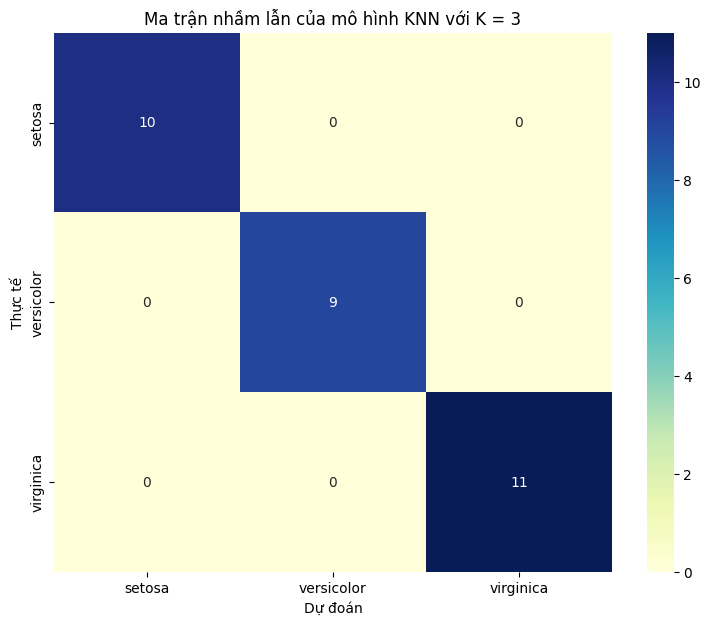

In [ ]:
k = 3
knn_model = KNeighborsClassifier(n_neighbors=k)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Độ chính xác ccuar mô hình KNN với K = {k}: {accuracy:.2f}")
print("Ma trận nhầm lẫn: ")
print(confusion_matrix)
print("Báo cáo phân loại: ")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(9,7))
sns.heatmap(conf_matrix, annot=True, cmap="YlGnBu", fmt="d", xticklabels = iris.target_names, yticklabels = iris.target_names)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title(f"Ma trận nhầm lẫn của mô hình KNN với K = {k}")
plt.show()

**SVM MINH HỌA**

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
cancer = datasets.load_breast_cancer()
X = cancer.data
y = cancer.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Độ chính xác của mô hình SVM: 0.98
Ma trận nhầm lẫn:
[[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



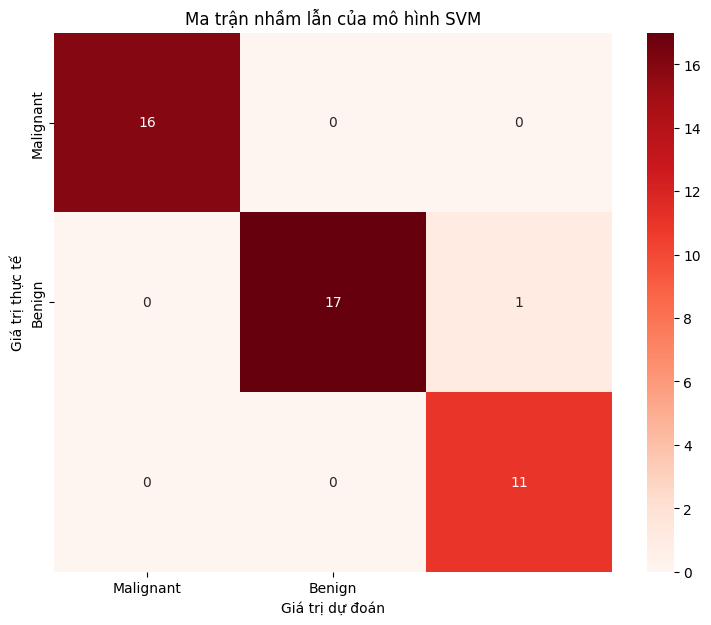

In [ ]:
svm_model = SVC(kernel = 'rbf', C = 2, gamma = 'scale')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Độ chính xác của mô hình SVM: {accuracy:.2f}")
print("Ma trận nhầm lẫn:")
print(conf_matrix)
print("Báo cáo phân loại:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(9, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds", xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.xlabel("Giá trị dự đoán")
plt.ylabel("Giá trị thực tế")
plt.title(("Ma trận nhầm lẫn của mô hình SVM"))
plt.show()

**BÀI 1 Ở LỚP**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
data = load_wine()
X = data.data
y = data.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


 Khoảng cách: euclidean => K tối ưu: 3, Độ chính xác cao nhất: 0.978

 Khoảng cách: manhattan => K tối ưu: 3, Độ chính xác cao nhất: 0.978

 Khoảng cách: minkowski => K tối ưu: 3, Độ chính xác cao nhất: 0.978


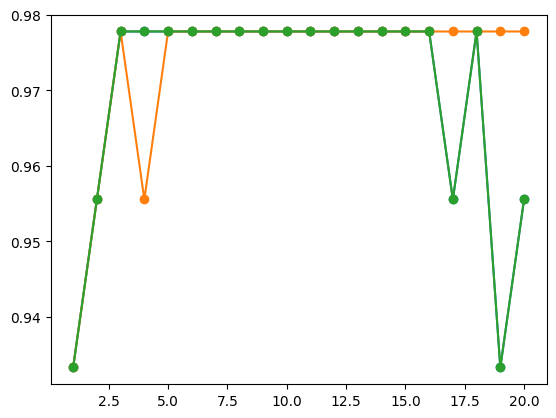

In [ ]:
k_values = range(1, 21)
metrics = ['euclidean', 'manhattan', 'minkowski']

for metric in metrics:
    accuracies = []

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)

    plt.plot(k_values, accuracies, marker='o', label=f'{metric}')

    best_k = k_values[np.argmax(accuracies)]
    best_acc = max(accuracies)
    print(f"\n Khoảng cách: {metric} => K tối ưu: {best_k}, Độ chính xác cao nhất: {best_acc:.3f}")

Báo cáo phân loại:
              precision    recall  f1-score   support

      setosa       0.95      1.00      0.97        19
  versicolor       1.00      0.95      0.98        21
   virginica       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



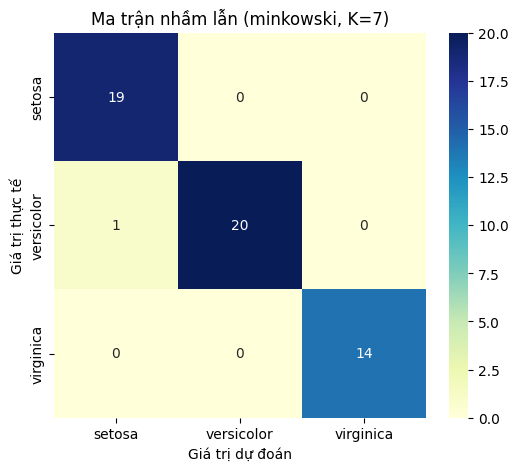

In [ ]:
    best_knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    best_knn.fit(X_train, y_train)
    y_pred_best = best_knn.predict(X_test)

    conf_matrix = confusion_matrix(y_test, y_pred_best)

    print("Báo cáo phân loại:")
    print(classification_report(y_test, y_pred_best, target_names=iris.target_names))

    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    plt.title(f"Ma trận nhầm lẫn ({metric}, K={best_k})")
    plt.xlabel("Giá trị dự đoán")
    plt.ylabel("Giá trị thực tế")
    plt.show()

**BÀI 2 Ở LỚP**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("housing.csv")
print("Kích thước dữ liệu:", df.shape)
print(df.head(10))
print("\nThông tin dữ liệu")
df.info()

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

Kích thước dữ liệu: (489, 4)
      RM  LSTAT  PTRATIO      MEDV
0  6.575   4.98     15.3  504000.0
1  6.421   9.14     17.8  453600.0
2  7.185   4.03     17.8  728700.0
3  6.998   2.94     18.7  701400.0
4  7.147   5.33     18.7  760200.0
5  6.430   5.21     18.7  602700.0
6  6.012  12.43     15.2  480900.0
7  6.172  19.15     15.2  569100.0
8  5.631  29.93     15.2  346500.0
9  6.004  17.10     15.2  396900.0

Thông tin dữ liệu
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    float64
dtypes: float64(4)
memory usage: 15.4 KB


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
k_values = [3, 5, 7, 9]
mse_scores = []
r2_scores = []

for k in k_values:
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_train, y_train)
    y_pred = knn_reg.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mse_scores.append(mse)
    r2_scores.append(r2)

    print(f"\nVới K = {k}")
    print(f"Mean Squared Error (MSE): {mse:.3f}")
    print(f"R² Score: {r2:.3f}")



Với K = 3
Mean Squared Error (MSE): 4465035000.000
R² Score: 0.797

Với K = 5
Mean Squared Error (MSE): 4071704400.000
R² Score: 0.815

Với K = 7
Mean Squared Error (MSE): 4307440408.163
R² Score: 0.804

Với K = 9
Mean Squared Error (MSE): 4361065000.000
R² Score: 0.802


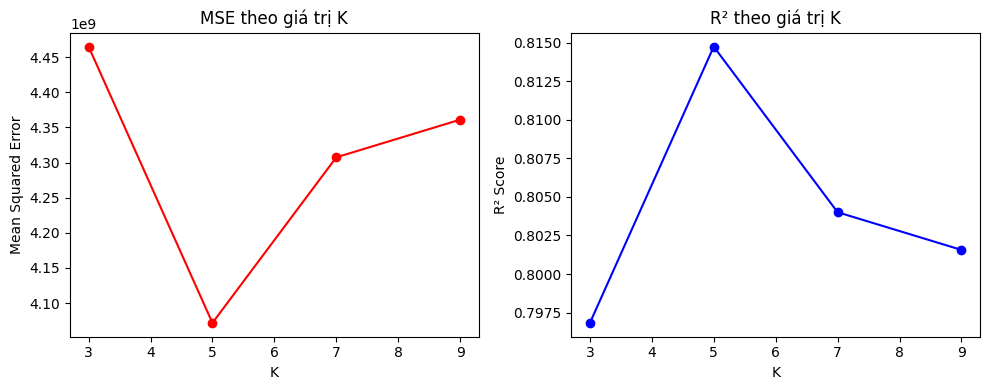

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(k_values, mse_scores, marker='o', color='r')
plt.title("MSE theo giá trị K")
plt.xlabel("K")
plt.ylabel("Mean Squared Error")

plt.subplot(1,2,2)
plt.plot(k_values, r2_scores, marker='o', color='b')
plt.title("R² theo giá trị K")
plt.xlabel("K")
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()

**BÀI 3 Ở LỚP**

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [ ]:
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]
print("Một vài dòng dữ liệu đầu tiên:")
print(df.head(5))

Một vài dòng dữ liệu đầu tiên:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


Thử nghiệm với tỉ lệ train/test = 60/40

Kernel = linear
Accuracy: 0.9500
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.90      0.95      0.93        20
   virginica       0.95      0.90      0.92        20

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



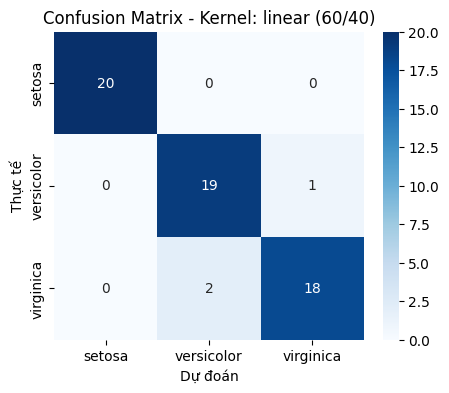


Kernel = poly
Accuracy: 0.8833
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.74      1.00      0.85        20
   virginica       1.00      0.65      0.79        20

    accuracy                           0.88        60
   macro avg       0.91      0.88      0.88        60
weighted avg       0.91      0.88      0.88        60



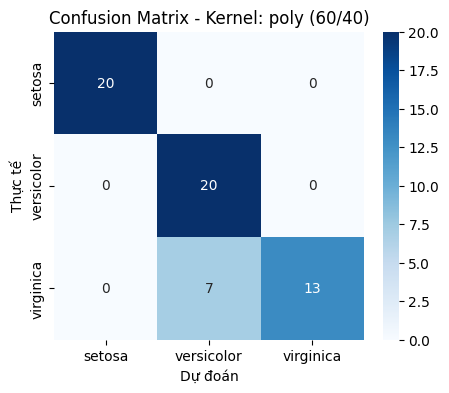


Kernel = rbf
Accuracy: 0.9500
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.90      0.95      0.93        20
   virginica       0.95      0.90      0.92        20

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



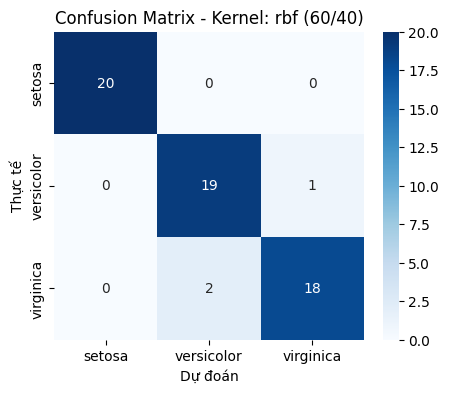


Kernel = sigmoid
Accuracy: 0.8833
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.93      0.70      0.80        20
   virginica       0.76      0.95      0.84        20

    accuracy                           0.88        60
   macro avg       0.90      0.88      0.88        60
weighted avg       0.90      0.88      0.88        60



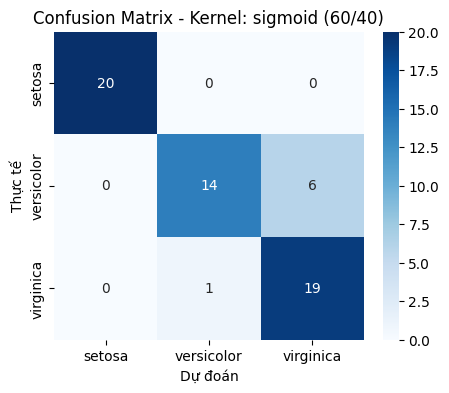

Thử nghiệm với tỉ lệ train/test = 70/30

Kernel = linear
Accuracy: 0.9111
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



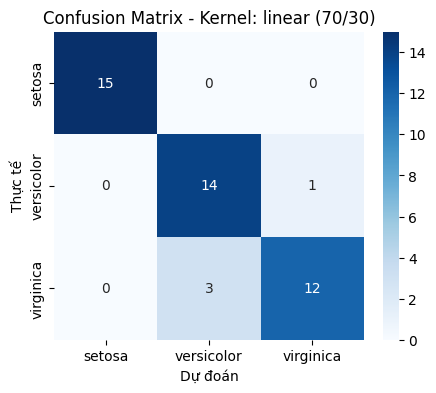


Kernel = poly
Accuracy: 0.8667
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.71      1.00      0.83        15
   virginica       1.00      0.60      0.75        15

    accuracy                           0.87        45
   macro avg       0.90      0.87      0.86        45
weighted avg       0.90      0.87      0.86        45



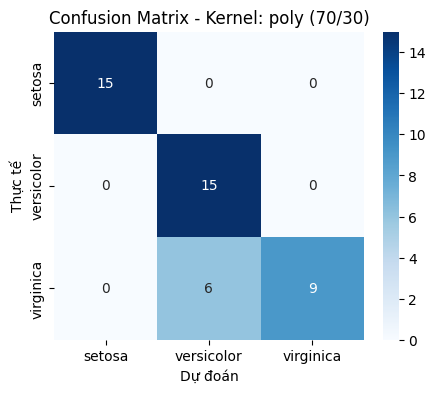


Kernel = rbf
Accuracy: 0.9333
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



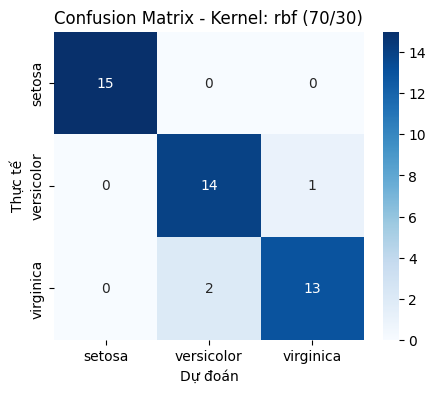


Kernel = sigmoid
Accuracy: 0.9111
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.92      0.80      0.86        15
   virginica       0.82      0.93      0.88        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



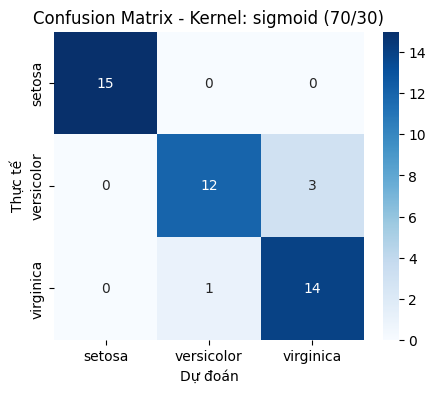

Thử nghiệm với tỉ lệ train/test = 80/20

Kernel = linear
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



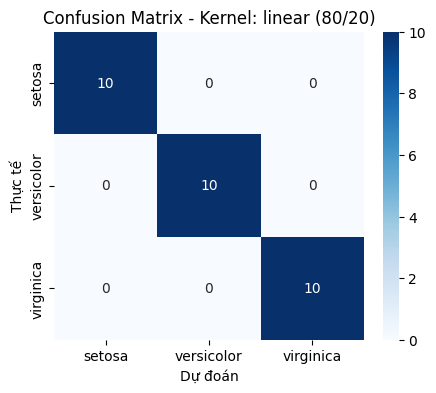


Kernel = poly
Accuracy: 0.9000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.70      0.82        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



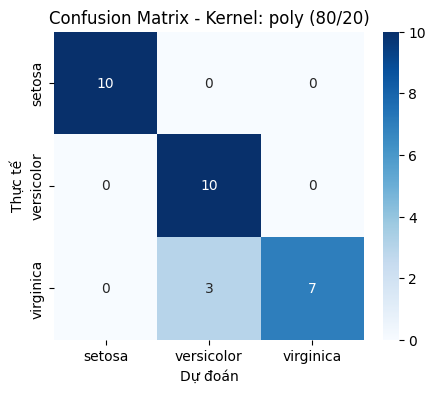


Kernel = rbf
Accuracy: 0.9667
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



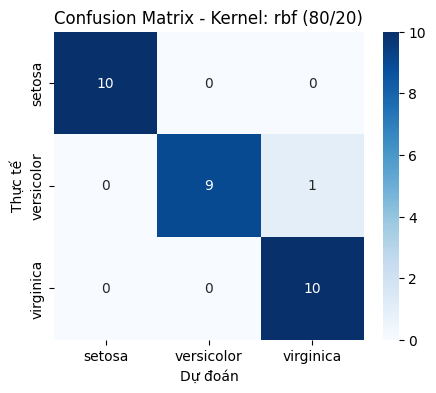


Kernel = sigmoid
Accuracy: 0.9000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.70      0.82        10
   virginica       0.77      1.00      0.87        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



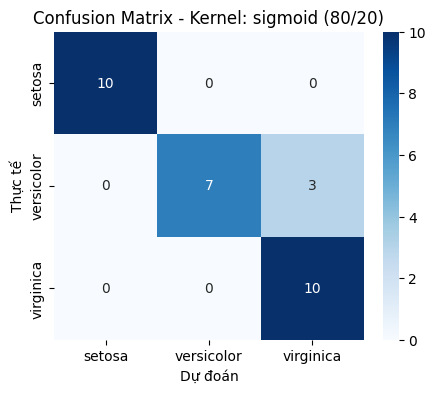


--------------------------------
BẢNG TỔNG HỢP KẾT QUẢ:
   Train/Test   Kernel  Accuracy
0       60/40   linear  0.950000
1       60/40     poly  0.883333
2       60/40      rbf  0.950000
3       60/40  sigmoid  0.883333
4       70/30   linear  0.911111
5       70/30     poly  0.866667
6       70/30      rbf  0.933333
7       70/30  sigmoid  0.911111
8       80/20   linear  1.000000
9       80/20     poly  0.900000
10      80/20      rbf  0.966667
11      80/20  sigmoid  0.900000


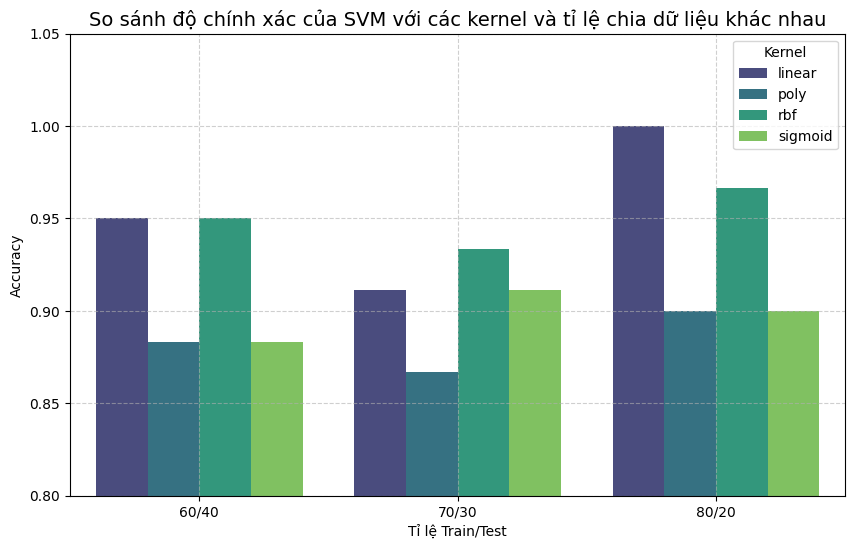

In [ ]:
split_ratios = [(0.6, 0.4), (0.7, 0.3), (0.8, 0.2)]
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = []
for train_ratio, test_ratio in split_ratios:
    print(f"Thử nghiệm với tỉ lệ train/test = {int(train_ratio*100)}/{int(test_ratio*100)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for kernel in kernels:
        svm_model = SVC(kernel=kernel, C=1.0, gamma='scale')
        svm_model.fit(X_train_scaled, y_train)
        y_pred = svm_model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        results.append({
            'Train/Test': f"{int(train_ratio*100)}/{int(test_ratio*100)}",
            'Kernel': kernel,
            'Accuracy': acc
        })

        print(f"\nKernel = {kernel}")
        print(f"Accuracy: {acc:.4f}")
        #print("Confusion Matrix:")
        conf_matrix = confusion_matrix(y_test, y_pred)
        #print(conf_matrix)
        print("Classification Report:")
        print(classification_report(y_test, y_pred, target_names=target_names))

        plt.figure(figsize=(5, 4))
        sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
                    xticklabels=target_names, yticklabels=target_names)
        plt.title(f"Confusion Matrix - Kernel: {kernel} ({int(train_ratio*100)}/{int(test_ratio*100)})")
        plt.xlabel("Dự đoán")
        plt.ylabel("Thực tế")
        plt.show()

results_df = pd.DataFrame(results)
print("\n--------------------------------")
print("BẢNG TỔNG HỢP KẾT QUẢ:")
print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Train/Test', y='Accuracy', hue='Kernel', data=results_df, palette='viridis')
plt.title("So sánh độ chính xác của SVM với các kernel và tỉ lệ chia dữ liệu khác nhau", fontsize=14)
plt.xlabel("Tỉ lệ Train/Test")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.05)
plt.legend(title="Kernel")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**BÀI 4 Ở LỚP**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("housing.csv")

print("10 dòng đầu tiên của dữ liệu:")
print(df.head(10))
print("\nThông tin dữ liệu")
df.info()

10 dòng đầu tiên của dữ liệu:
      RM  LSTAT  PTRATIO      MEDV
0  6.575   4.98     15.3  504000.0
1  6.421   9.14     17.8  453600.0
2  7.185   4.03     17.8  728700.0
3  6.998   2.94     18.7  701400.0
4  7.147   5.33     18.7  760200.0
5  6.430   5.21     18.7  602700.0
6  6.012  12.43     15.2  480900.0
7  6.172  19.15     15.2  569100.0
8  5.631  29.93     15.2  346500.0
9  6.004  17.10     15.2  396900.0

Thông tin dữ liệu
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    float64
dtypes: float64(4)
memory usage: 15.4 KB


In [ ]:
print("\nKiểm tra giá trị bị thiếu:")
print(df.isnull().sum())


Kiểm tra giá trị bị thiếu:
RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64


In [ ]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

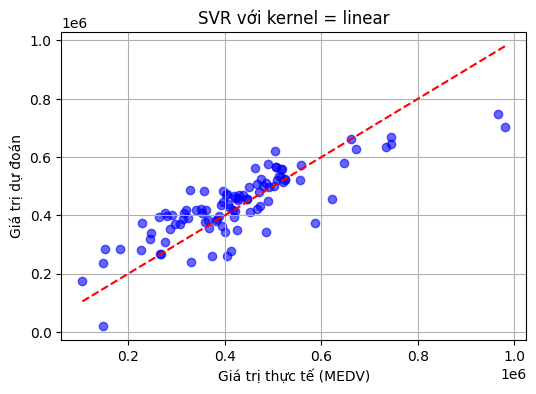

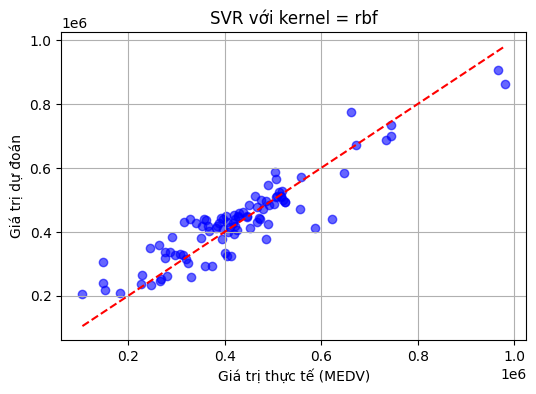

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

kernels = ['linear', 'rbf']
results = []

for kernel in kernels:
    svr = SVR(kernel=kernel)
    svr.fit(X_train_scaled, y_train_scaled)
    y_pred_scaled = svr.predict(X_test_scaled)

    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append((kernel, mse, r2))

    plt.figure(figsize=(6,4))
    plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f"SVR với kernel = {kernel}")
    plt.xlabel("Giá trị thực tế (MEDV)")
    plt.ylabel("Giá trị dự đoán")
    plt.grid(True)
    plt.show()

In [ ]:
for kernel, mse, r2 in results:
    print(f"Kernel: {kernel}")
    print(f"  Mean Squared Error (MSE): {mse:.4f}")
    print(f"  R² Score: {r2:.4f}")
    print("\n")

Kernel: linear
  Mean Squared Error (MSE): 6811006475.8409
  R² Score: 0.6901


Kernel: rbf
  Mean Squared Error (MSE): 3555494194.7716
  R² Score: 0.8382




**BÀI 1 Ở NHÀ**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Kernel = linear
Accuracy = 0.9111
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



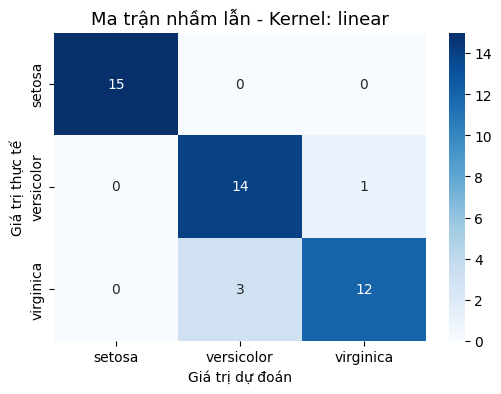


Kernel = poly
Accuracy = 0.8667
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.71      1.00      0.83        15
   virginica       1.00      0.60      0.75        15

    accuracy                           0.87        45
   macro avg       0.90      0.87      0.86        45
weighted avg       0.90      0.87      0.86        45



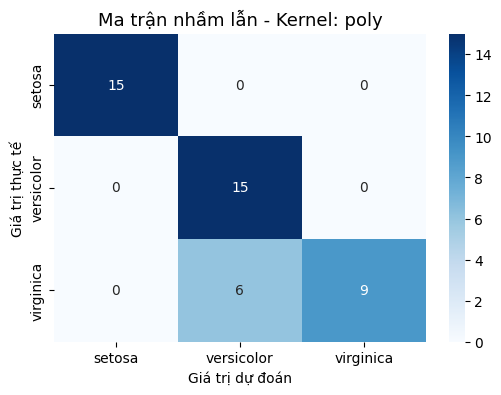


Kernel = rbf
Accuracy = 0.9333
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



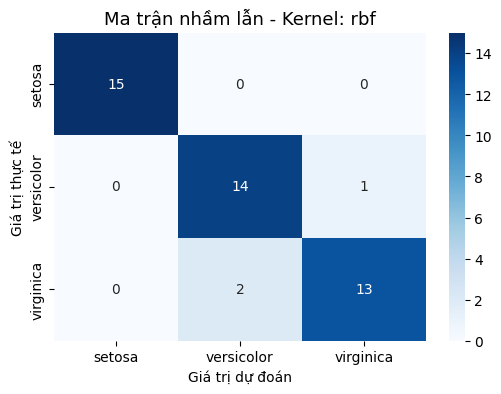


Kernel = sigmoid
Accuracy = 0.9111
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.92      0.80      0.86        15
   virginica       0.82      0.93      0.88        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



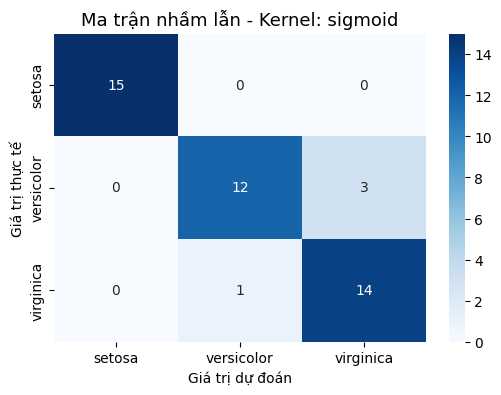

In [ ]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = []

for kernel in kernels:
    # Huấn luyện mô hình
    svm = SVC(kernel=kernel, C=1.0, gamma='scale')
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)

    # Tính độ chính xác
    acc = accuracy_score(y_test, y_pred)
    results.append({'Kernel': kernel, 'Accuracy': acc})

    # In kết quả
    print(f"\nKernel = {kernel}")
    print(f"Accuracy = {acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Ma trận nhầm lẫn - Kernel: {kernel}", fontsize=13)
    plt.xlabel("Giá trị dự đoán")
    plt.ylabel("Giá trị thực tế")
    plt.show()


/tmp/ipython-input-1443193017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Kernel', y='Accuracy', data=results_df, palette='viridis')


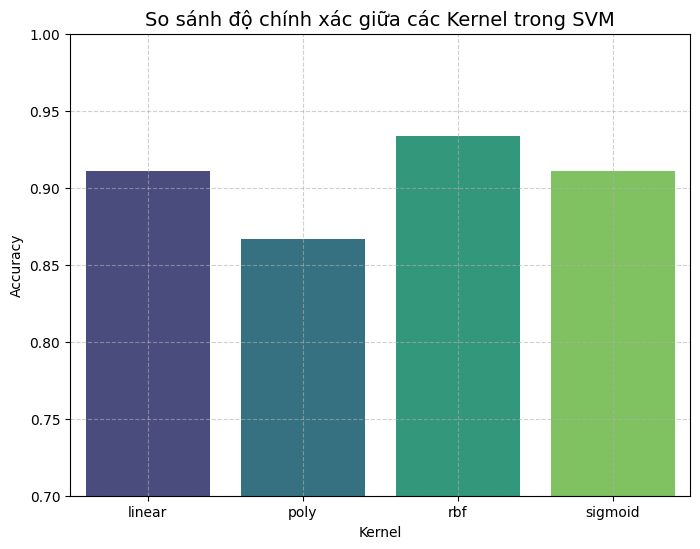

In [ ]:
results_df = pd.DataFrame(results)
plt.figure(figsize=(8,6))
sns.barplot(x='Kernel', y='Accuracy', data=results_df, palette='viridis')
plt.title("So sánh độ chính xác giữa các Kernel trong SVM", fontsize=14)
plt.ylim(0.7, 1.00)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**BÀI 2 VỀ NHÀ**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target
target_names = data.target_names

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, cv=5, verbose=0)
grid.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']})

In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best Score (CV Accuracy):", grid.best_score_)

Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best Score (CV Accuracy): 0.980952380952381


In [ ]:
y_pred = grid.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)


Accuracy on Test Set: 0.9333
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



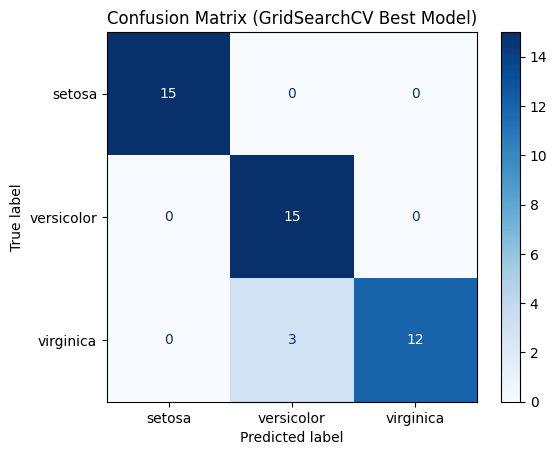

In [ ]:
print(f"\nAccuracy on Test Set: {acc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix (GridSearchCV Best Model)")
plt.show()

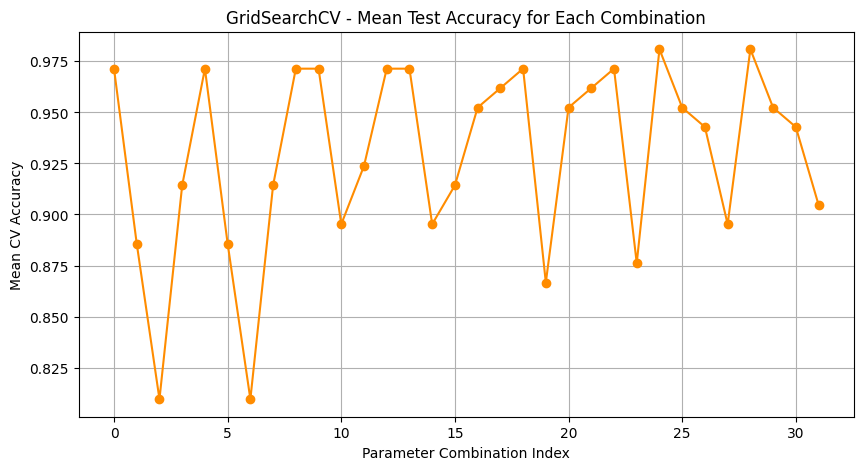

In [ ]:
results = pd.DataFrame(grid.cv_results_)
plt.figure(figsize=(10,5))
plt.plot(results['mean_test_score'], 'o-', color='darkorange')
plt.title('GridSearchCV - Mean Test Accuracy for Each Combination')
plt.xlabel('Parameter Combination Index')
plt.ylabel('Mean CV Accuracy')
plt.grid(True)
plt.show()

**BÀI 3 VỀ NHÀ**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [ ]:
digits = load_digits()
X = digits.data
y = digits.target
labels = digits.target_names

Số mẫu: 1797, Số đặc trưng: 64
Các nhãn: [0 1 2 3 4 5 6 7 8 9]


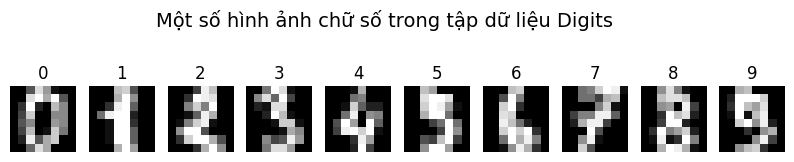

In [ ]:
print(f"Số mẫu: {X.shape[0]}, Số đặc trưng: {X.shape[1]}")
print("Các nhãn:", labels)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"{digits.target[i]}")
    plt.axis('off')
plt.suptitle("Một số hình ảnh chữ số trong tập dữ liệu Digits", fontsize=14)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
knn_params = {
    'n_neighbors': list(range(1, 16)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, knn_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)

print("KNN best parameters:", grid_knn.best_params_)
print("KNN best CV accuracy:", grid_knn.best_score_)

knn_best = grid_knn.best_estimator_
y_pred_knn = knn_best.predict(X_test_scaled)


KNN best parameters: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
KNN best CV accuracy: 0.9784117305458769


In [ ]:
svm_params = [
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.001]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10], 'degree': [2, 3], 'gamma': ['scale', 0.01], 'coef0': [0, 1]}
]

svm = SVC()
grid_svm = GridSearchCV(svm, svm_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

print("SVM best parameters:", grid_svm.best_params_)
print("SVM best CV accuracy:", grid_svm.best_score_)

svm_best = grid_svm.best_estimator_
y_pred_svm = svm_best.predict(X_test_scaled)


SVM best parameters: {'C': 10, 'coef0': 0, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}
SVM best CV accuracy: 0.9874709639953542



===== KNN =====
Accuracy: 0.9833
F1-score (macro): 0.9832
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      1.00      0.97        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.91      0.94        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



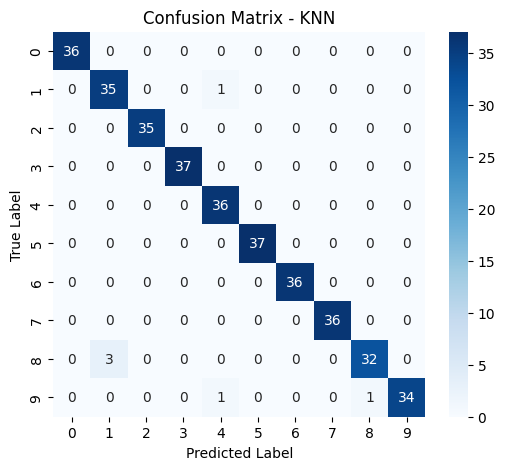


===== SVM =====
Accuracy: 0.9944
F1-score (macro): 0.9944
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.97      1.00      0.99        35
           9       1.00      0.97      0.99        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



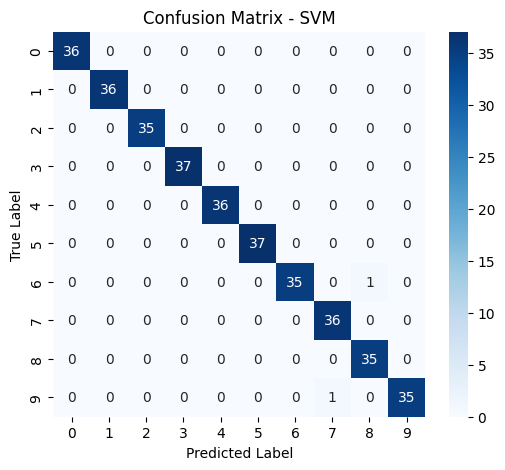

/tmp/ipython-input-2423992834.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accs, palette='magma')


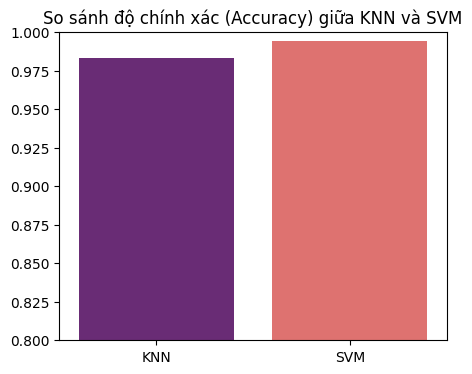

In [ ]:
def evaluate_model(y_true, y_pred, model_name, labels):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"\n===== {model_name} =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score (macro): {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=[str(l) for l in labels]))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    return acc, f1

acc_knn, f1_knn = evaluate_model(y_test, y_pred_knn, "KNN", labels)
acc_svm, f1_svm = evaluate_model(y_test, y_pred_svm, "SVM", labels)

models = ['KNN', 'SVM']
accs = [acc_knn, acc_svm]
plt.figure(figsize=(5,4))
sns.barplot(x=models, y=accs, palette='magma')
plt.title("So sánh độ chính xác (Accuracy) giữa KNN và SVM")
plt.ylim(0.8, 1.0)
plt.show()


KNN: Có 6 mẫu bị dự đoán sai.


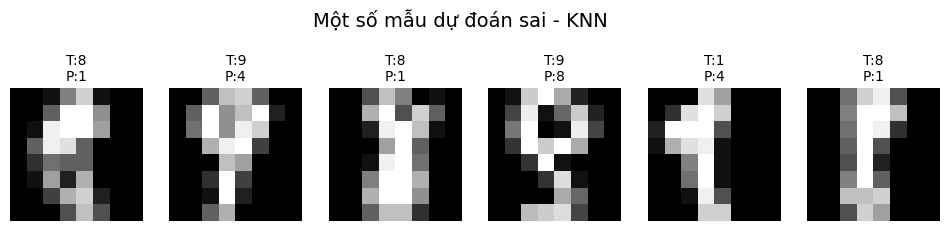

SVM: Có 2 mẫu bị dự đoán sai.


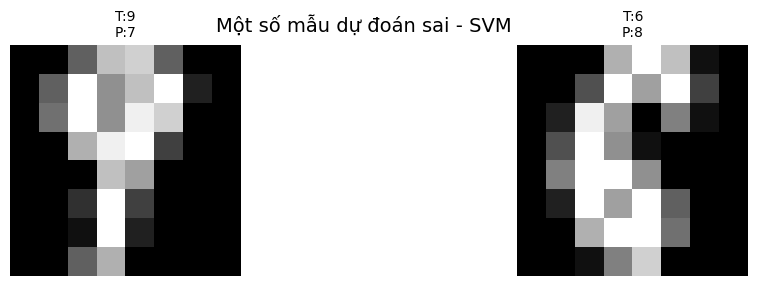

In [ ]:
def show_misclassified(X_test_orig, y_true, y_pred, model_name, n=10):
    mis_idx = np.where(y_true != y_pred)[0]
    print(f"{model_name}: Có {len(mis_idx)} mẫu bị dự đoán sai.")

    if len(mis_idx) == 0:
        print("Không có mẫu sai.")
        return

    np.random.seed(42)
    sel = np.random.choice(mis_idx, size=min(n, len(mis_idx)), replace=False)

    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(sel):
        ax = plt.subplot(1, len(sel), i+1)
        ax.imshow(X_test_orig[idx].reshape(8, 8), cmap='gray')
        ax.set_title(f"T:{y_true[idx]}\nP:{y_pred[idx]}", fontsize=10)
        ax.axis('off')
    plt.suptitle(f"Một số mẫu dự đoán sai - {model_name}", fontsize=14)
    plt.show()

show_misclassified(X_test, y_test, y_pred_knn, "KNN")
show_misclassified(X_test, y_test, y_pred_svm, "SVM")
